In [19]:
!pip install jax jaxlib torch torchvision matplotlib

# PyTorch `torch.compile` Analysis
### Backends · Debugging Compilation Failures · Graph Capture & Inspection

This notebook systematically dissects `torch.compile` across three experiments:
1. **Part 1** — Comparing compilation backends on a 3-layer MLP
2. **Part 2** — Diagnosing and fixing problematic functions
3. **Part 3** — Graph capture, inspection, and IR visualisation

In [20]:
#Imports & environment report
import time
import warnings
import textwrap
import io
import re
from contextlib import redirect_stdout
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch._dynamo as dynamo

warnings.filterwarnings('ignore')
dynamo.reset()   # clean slate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PALETTE = ['#2D6A9F', '#E07B39', '#3A9E6A', '#A94EC3', '#C93D3D', '#6B6B6B']

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
else:
    print('Running on CPU — cudagraphs backend will be skipped')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


---
## Part 1 — Comparing Backends

We build a 3-layer MLP with ReLU activations and benchmark four compilation backends
across 100 forward + backward passes each.

In [21]:
#Model definition
class MLP(nn.Module):
    """3-layer MLP with ReLU activations."""
    def __init__(self, in_dim=1024, hidden=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

#Benchmark helper
BATCH     = 256
IN_DIM    = 1024
OUT_DIM   = 512
N_WARMUP  = 10
N_RUNS    = 100

def benchmark_model(model, backend_name, n_warmup=N_WARMUP, n_runs=N_RUNS):
    """Time forward+backward over n_runs; return (mean_ms, std_ms, first_call_ms)."""
    model = model.to(DEVICE)
    x     = torch.randn(BATCH, IN_DIM,  device=DEVICE)
    target = torch.randn(BATCH, OUT_DIM, device=DEVICE)
    loss_fn = nn.MSELoss()

    def one_step():
        out  = model(x)
        loss = loss_fn(out, target)
        loss.backward()
        # zero grads so memory stays stable
        for p in model.parameters():
            p.grad = None

    def timed_step():
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        one_step()
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) * 1e3   # ms

    # First call (includes compilation for non-eager backends)
    first_ms = timed_step()

    # Warm-up
    for _ in range(n_warmup - 1):
        one_step()

    # Timed runs
    times = [timed_step() for _ in range(n_runs)]
    return float(np.mean(times)), float(np.std(times)), first_ms

print('Model architecture:')
model_demo = MLP()
print(model_demo)
total_params = sum(p.numel() for p in model_demo.parameters())
print(f'\nTotal parameters: {total_params:,}')

Model architecture:
MLP(
  (fc1): Linear(in_features=1024, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=2048, bias=True)
  (fc3): Linear(in_features=2048, out_features=512, bias=True)
)

Total parameters: 7,344,640


In [22]:
#Run backend comparison
#Backends available depends on CUDA; skip cudagraphs on CPU
BACKENDS = ['eager', 'aot_eager', 'inductor']
if DEVICE == 'cuda':
    BACKENDS.append('cudagraphs')

results = {}  # backend -> (mean_ms, std_ms, first_ms)

print(f"{'Backend':<14} {'1st call (ms)':>14} {'Mean (ms)':>11} {'Std (ms)':>10}")
print("-" * 55)

for backend in BACKENDS:
    dynamo.reset()  # clear any cached graphs between backends
    base_model = MLP().to(DEVICE)

    if backend == 'eager':
        model_under_test = base_model
    else:
        try:
            model_under_test = torch.compile(base_model, backend=backend)
        except Exception as e:
            print(f"{backend:<14}  SKIPPED: {e}")
            continue

    try:
        mean_ms, std_ms, first_ms = benchmark_model(model_under_test, backend)
        results[backend] = (mean_ms, std_ms, first_ms)
        print(f"{backend:<14} {first_ms:>14.2f} {mean_ms:>11.2f} {std_ms:>10.2f}")
    except Exception as e:
        print(f"{backend:<14}  ERROR: {e}")

Backend         1st call (ms)   Mean (ms)   Std (ms)
-------------------------------------------------------
eager                    6.28        3.68       0.51
aot_eager              157.07        3.37       0.34
inductor               113.48        3.34       0.36
cudagraphs             166.06        3.56       0.19


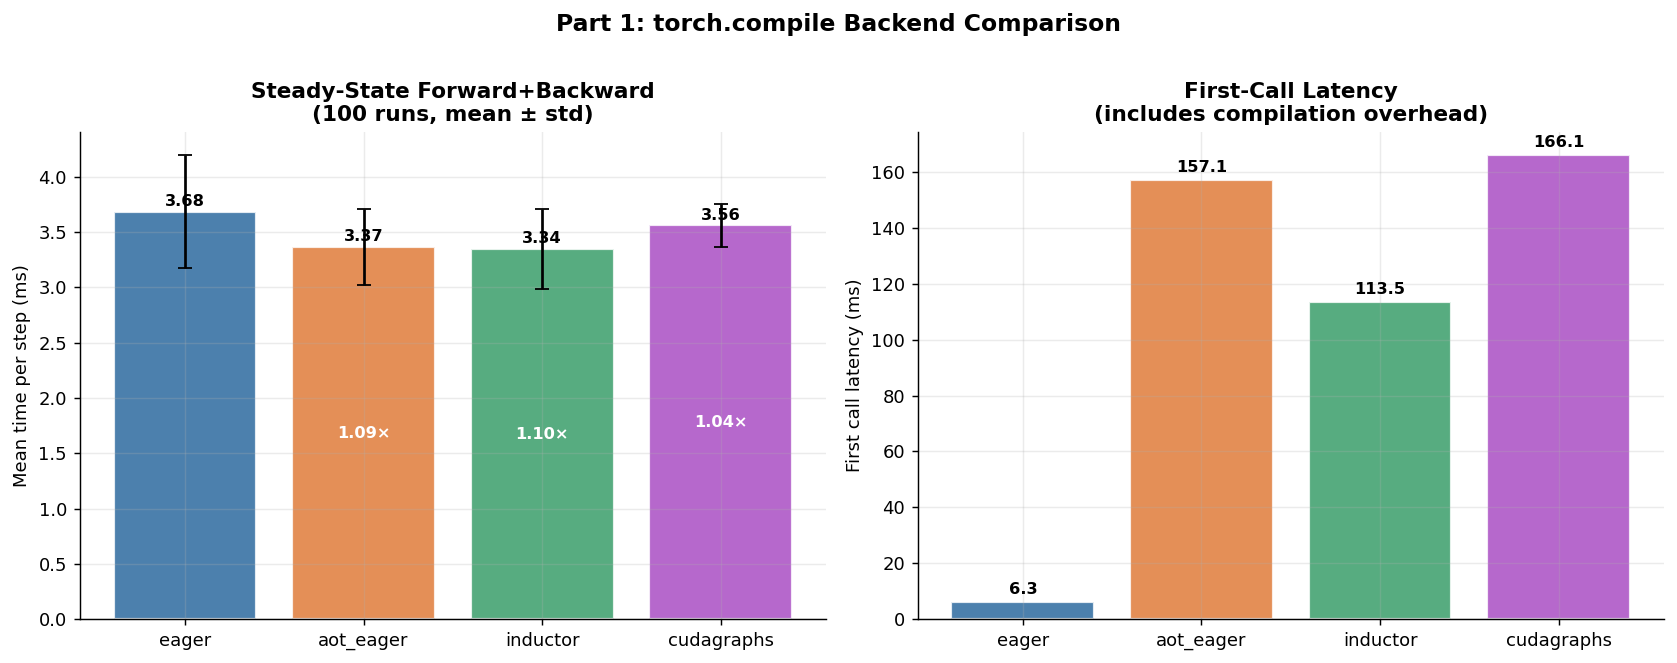

Saved: part1_backends.png


In [23]:
#Plot: backend comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
backends_ran  = list(results.keys())
mean_times    = [results[b][0] for b in backends_ran]
std_times     = [results[b][1] for b in backends_ran]
first_times   = [results[b][2] for b in backends_ran]
colors        = [PALETTE[i % len(PALETTE)] for i in range(len(backends_ran))]

# --- Steady-state mean latency
ax = axes[0]
bars = ax.bar(backends_ran, mean_times, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.2, yerr=std_times, capsize=4)
ax.set_ylabel('Mean time per step (ms)')
ax.set_title('Steady-State Forward+Backward\n(100 runs, mean ± std)', fontweight='bold')
for bar, t in zip(bars, mean_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(std_times)*0.05,
            f'{t:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotate speedup vs eager
eager_ms = results.get('eager', (mean_times[0],))[0]
for bar, b in zip(bars, backends_ran):
    if b != 'eager':
        sp = eager_ms / results[b][0]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2,
                f'{sp:.2f}×', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

# --- First-call (compilation) latency
ax2 = axes[1]
bars2 = ax2.bar(backends_ran, first_times, color=colors, alpha=0.85,
                edgecolor='white', linewidth=1.2)
ax2.set_ylabel('First call latency (ms)')
ax2.set_title('First-Call Latency\n(includes compilation overhead)', fontweight='bold')
for bar, t in zip(bars2, first_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(first_times)*0.01,
             f'{t:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Part 1: torch.compile Backend Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('part1_backends.png', bbox_inches='tight')
plt.show()
print('Saved: part1_backends.png')

### Part 1 Analysis — Why Do Different Backends Have Different Performance?

Each backend represents a different point in the **compile-time cost vs. runtime performance** tradeoff:

| Backend | What it does | Compile overhead | Runtime gain |
|---------|-------------|------------------|--------------|
| `eager` | No compilation — standard PyTorch dispatch | None | Baseline |
| `aot_eager` | Traces the forward+backward graph with **AOTAutograd**, but uses standard PyTorch kernels to execute | Low | Minimal — mainly removes Python overhead in backward |
| `inductor` | AOTAutograd trace + **Triton kernel codegen** via the Inductor compiler; fuses ops, optimises memory layout, generates custom CUDA/C++ | High (~seconds) | Best — fused kernels, reduced memory traffic |
| `cudagraphs` | Records all CUDA API calls into a **replayable CUDA Graph**; eliminates CPU-GPU synchronisation and kernel launch overhead entirely | Medium | Very good for small, fixed-shape workloads |

**Tradeoffs to know:**
- `inductor` wins at steady state because Triton kernel fusion reduces global memory round-trips (same principle as JAX XLA fusion in Part 3 of the previous notebook). The high first-call cost is amortised over many subsequent calls.
- `cudagraphs` is ideal for inference loops with static shapes (no reallocation on every step). It breaks if tensor shapes or control flow change between calls.
- `aot_eager` is a useful debugging tool: it exercises the AOTAutograd tracing machinery without Inductor, so you can isolate whether a bug is in tracing or in kernel codegen.
- On CPU the CUDA-specific backends are unavailable; `inductor` falls back to C++ kernel generation instead of Triton.

---
## Part 2 — Debugging Compilation Failures

We examine three problematic functions, explain **why** each causes issues, then present the fixed version.

In [24]:
# ── Utility: run dynamo.explain and pretty-print the summary ──────────────
def explain(fn, *args, label=''):
    """Call torch._dynamo.explain and print a clean summary."""
    dynamo.reset()
    try:
        explanation = dynamo.explain(fn)(*args)
        print(f"{'─'*60}")
        print(f"  {label}")
        print(f"{'─'*60}")
        print(f"  Graph count      : {explanation.graph_count}")
        print(f"  Graph break count: {explanation.graph_break_count}")
        print(f"  Break reasons:")
        seen = set()
        for reason in explanation.break_reasons:
            msg = str(reason.reason)[:120]
            if msg not in seen:
                print(f"    • {msg}")
                seen.add(msg)
        print()
    except Exception as e:
        print(f"  explain() raised: {type(e).__name__}: {e}\n")

In [25]:
#  PROBLEM 1 — data-dependent control flow
def problem1(x):
    """BROKEN: if-branch depends on a runtime tensor value."""
    if x.sum() > 0:      # .sum() returns a tensor; comparison materialises a Python bool
        return x * 2
    else:
        return x / 2

x_test = torch.randn(64, 64)
explain(problem1, x_test, label='problem1 — data-dependent if')

#Why it fails
print(textwrap.dedent("""
WHY IT FAILS
────────────
torch.compile traces through Python bytecode with symbolic values.
When it reaches `x.sum() > 0`, the comparison forces a concrete Python
bool — but the tensor hasn't been evaluated yet (it's a symbolic tracer).
Dynamo inserts a graph break at this point and falls back to Python for
the conditional, producing two separate sub-graphs (one per branch) that
are recompiled every time the branch direction changes.
This defeats operator fusion and adds re-compilation overhead.
"""))

#Fix: use torch.where (data-dependent selection, no Python branch)
@torch.compile
def fixed1(x):
    """FIXED: torch.where expresses the conditional inside the graph."""
    mask = (x.sum() > 0).float()       # stays symbolic
    return x * 2 * mask + (x / 2) * (1 - mask)

# Alternatively — the idiomatic torch.where:
@torch.compile
def fixed1_alt(x):
    """FIXED (cleaner): torch.where on an elementwise predicate."""
    return torch.where(x > 0, x * 2, x / 2)

print('fixed1 output matches problem1:', torch.allclose(fixed1(x_test), problem1(x_test)))

# Explain the fixed version
dynamo.reset()
explain(fixed1_alt, x_test, label='fixed1_alt — torch.where (no graph break)')

────────────────────────────────────────────────────────────
  problem1 — data-dependent if
────────────────────────────────────────────────────────────
  Graph count      : 2
  Graph break count: 1
  Break reasons:
    • generic_jump TensorVariable()


WHY IT FAILS
────────────
torch.compile traces through Python bytecode with symbolic values.
When it reaches `x.sum() > 0`, the comparison forces a concrete Python
bool — but the tensor hasn't been evaluated yet (it's a symbolic tracer).
Dynamo inserts a graph break at this point and falls back to Python for
the conditional, producing two separate sub-graphs (one per branch) that
are recompiled every time the branch direction changes.
This defeats operator fusion and adds re-compilation overhead.

fixed1 output matches problem1: True
────────────────────────────────────────────────────────────
  fixed1_alt — torch.where (no graph break)
────────────────────────────────────────────────────────────
  Graph count      : 1
  Graph break cou

In [26]:
#  PROBLEM 2 — Python dict with tensor values

def problem2(x):
    """SUBOPTIMAL: tensor stored in a Python dict causes a graph break."""
    d = {}
    d['key'] = x           # dict mutation — Dynamo must track Python-side state
    return d['key'] * 2

explain(problem2, x_test, label='problem2 — tensor in Python dict')

print(textwrap.dedent("""
WHY IT'S SUBOPTIMAL
───────────────────
Dynamo *can* handle simple dict lookups in many cases, but dict mutations
(`d['key'] = x`) require Dynamo to track Python-level side-effects that
are outside the tensor graph. Depending on the PyTorch version, this
may cause a graph break or result in a larger guard set (more conditions
that must be re-verified on each call), adding overhead.

More importantly: storing tensors in dicts / lists is a common pattern
that silently prevents fusion — each dict access is a Python-level
operation that Dynamo must model, not a native graph op.
"""))

#Fix: pass tensors directly; avoid unnecessary Python containers
@torch.compile
def fixed2(x):
    """FIXED: operate on tensors directly — no dict indirection."""
    return x * 2

# If you genuinely need multiple named outputs, use a namedtuple or return tuple
from collections import namedtuple
Output = namedtuple('Output', ['result'])

@torch.compile
def fixed2_named(x):
    """FIXED: namedtuple is understood by Dynamo and doesn't break the graph."""
    return Output(result=x * 2)

print('fixed2 output matches problem2:', torch.allclose(fixed2(x_test), problem2(x_test)))
dynamo.reset()
explain(fixed2, x_test, label='fixed2 — direct tensor op (no dict)')

────────────────────────────────────────────────────────────
  problem2 — tensor in Python dict
────────────────────────────────────────────────────────────
  Graph count      : 1
  Graph break count: 0
  Break reasons:


WHY IT'S SUBOPTIMAL
───────────────────
Dynamo *can* handle simple dict lookups in many cases, but dict mutations
(`d['key'] = x`) require Dynamo to track Python-level side-effects that
are outside the tensor graph. Depending on the PyTorch version, this
may cause a graph break or result in a larger guard set (more conditions
that must be re-verified on each call), adding overhead.

More importantly: storing tensors in dicts / lists is a common pattern
that silently prevents fusion — each dict access is a Python-level
operation that Dynamo must model, not a native graph op.

fixed2 output matches problem2: True
────────────────────────────────────────────────────────────
  fixed2 — direct tensor op (no dict)
────────────────────────────────────────────────────────────

In [27]:
#  PROBLEM 3 — Python loop accumulating scalar .sum() results
def problem3(x):
    """SUBOPTIMAL: Python int accumulator + loop unrolls into a huge graph."""
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

explain(problem3, x_test, label='problem3 — loop with Python int accumulator')

print(textwrap.dedent("""
WHY IT'S SUBOPTIMAL
───────────────────
`result = 0` is a Python int, not a tensor. Dynamo CAN trace through
this loop (it unrolls the range(10) statically), but each iteration
calls `.sum()` which returns a 0-d tensor, and the `+=` promotes the
Python int to a tensor mid-graph. This creates an unrolled graph with
10 separate `pow → sum → add` chains that are LESS fuseable than a
vectorised equivalent, and the loop unrolling makes the graph larger
than necessary, slowing compilation.

Additionally, `x ** i` for integer `i` is not as efficient as a
vectorised polynomial computation.
"""))

#Fix A: start accumulator as a zero tensor
@torch.compile
def fixed3_v1(x):
    """FIXED v1: use a tensor accumulator; loop still unrolls but stays in-graph."""
    result = torch.zeros((), device=x.device, dtype=x.dtype)
    for i in range(10):
        result = result + (x ** i).sum()
    return result

#Fix B: vectorise the polynomial via torch.stack
@torch.compile
def fixed3_v2(x):
    """FIXED v2: stack all powers into a tensor; single sum over them.

    This expresses the computation as a single batched operation —
    far more amenable to fusion and avoids loop unrolling entirely.
    """
    powers = torch.stack([x ** i for i in range(10)], dim=0)  # (10, *x.shape)
    return powers.sum()

# Verify correctness
ref = problem3(x_test)
print('fixed3_v1 matches:', torch.allclose(fixed3_v1(x_test).float(), ref.float(), atol=1e-4))
print('fixed3_v2 matches:', torch.allclose(fixed3_v2(x_test).float(), ref.float(), atol=1e-4))

dynamo.reset()
explain(fixed3_v2, x_test, label='fixed3_v2 — vectorised (no loop unrolling)')

────────────────────────────────────────────────────────────
  problem3 — loop with Python int accumulator
────────────────────────────────────────────────────────────
  Graph count      : 1
  Graph break count: 0
  Break reasons:


WHY IT'S SUBOPTIMAL
───────────────────
`result = 0` is a Python int, not a tensor. Dynamo CAN trace through
this loop (it unrolls the range(10) statically), but each iteration
calls `.sum()` which returns a 0-d tensor, and the `+=` promotes the
Python int to a tensor mid-graph. This creates an unrolled graph with
10 separate `pow → sum → add` chains that are LESS fuseable than a
vectorised equivalent, and the loop unrolling makes the graph larger
than necessary, slowing compilation.

Additionally, `x ** i` for integer `i` is not as efficient as a
vectorised polynomial computation.

fixed3_v1 matches: True
fixed3_v2 matches: True
────────────────────────────────────────────────────────────
  fixed3_v2 — vectorised (no loop unrolling)
───────────────────────

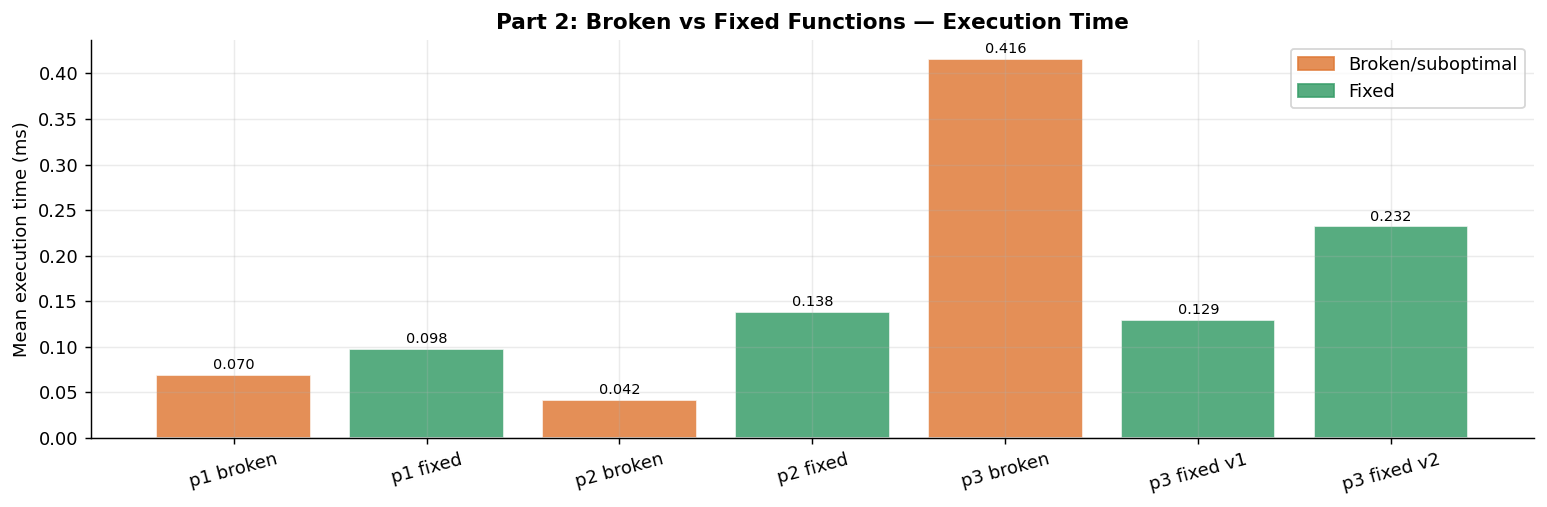

Saved: part2_debugging.png


In [28]:
#Benchmark: broken vs fixed
def bench(fn, x, n=200):
    # warm-up
    for _ in range(10): fn(x)
    times = []
    for _ in range(n):
        if DEVICE == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = fn(x)
        if isinstance(out, torch.Tensor):
          if out.numel==1:
            _ = out.item()
          else:
            _ = out.sum().item()
        if DEVICE == 'cuda': torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return np.mean(times)

dynamo.reset()
fns = {
    'p1 broken'  : problem1,
    'p1 fixed'   : fixed1_alt,
    'p2 broken'  : problem2,
    'p2 fixed'   : fixed2,
    'p3 broken'  : problem3,
    'p3 fixed v1': fixed3_v1,
    'p3 fixed v2': fixed3_v2,
}

bench_results = {name: bench(fn, x_test) for name, fn in fns.items()}

fig, ax = plt.subplots(figsize=(12, 4))
names  = list(bench_results.keys())
values = [bench_results[n] for n in names]
colors_bar = [PALETTE[1] if 'broken' in n else PALETTE[2] for n in names]
bars = ax.bar(names, values, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)
broken_patch = mpatches.Patch(color=PALETTE[1], alpha=0.85, label='Broken/suboptimal')
fixed_patch  = mpatches.Patch(color=PALETTE[2], alpha=0.85, label='Fixed')
ax.legend(handles=[broken_patch, fixed_patch])
ax.set_ylabel('Mean execution time (ms)')
ax.set_title('Part 2: Broken vs Fixed Functions — Execution Time', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('part2_debugging.png', bbox_inches='tight')
plt.show()
print('Saved: part2_debugging.png')

### Part 2 Summary

| Problem | Root Cause | Fix | Key Lesson |
|---------|-----------|-----|------------|
| `problem1` | `if tensor.sum() > 0` forces a concrete Python bool → graph break | Replace with `torch.where` or `torch.cond` | Never branch on tensor *values* inside compiled code |
| `problem2` | Dict mutation is a Python side-effect Dynamo must guard against | Pass tensors directly; use namedtuple for structured outputs | Tensor containers add guards, not graph ops |
| `problem3` | Python `int` accumulator + `range` loop unrolls into a huge graph; poor fusion | Use a zero-tensor accumulator, or better — vectorise with `torch.stack` | Initialise accumulators as tensors; prefer vectorised ops over explicit loops |

---
## Part 3 — Graph Capture and Inspection

We write a function with a mix of **capturable** (tensor ops) and **non-capturable** (Python side-effects) operations, then inspect the resulting FX graph.

In [29]:
# ── The function under inspection ─────────────────────────────────────────
side_effect_log = []   # global list we'll mutate inside the function

def inspected_fn(x, W1, W2, ln_weight, ln_bias):
    """
    Contains:
      ✅  2 matrix multiplications
      ✅  ReLU activation
      ✅  Residual connection
      ✅  Layer normalisation
      ⚠️  print() — Python side-effect
      ⚠️  list.append() — Python side-effect
    """
    # ── Capturable tensor ops ──────────────────────────────────────────────
    h = x @ W1                          # matmul 1
    h = F.relu(h)                       # ReLU
    h = h @ W2                          # matmul 2
    h = h + x                          # residual connection
    h = F.layer_norm(h, h.shape[-1:],  # layer norm
                     weight=ln_weight,
                     bias=ln_bias)

    # ── NON-capturable side effects ────────────────────────────────────────
    print("Hello from inside inspected_fn")  # print: Python I/O
    side_effect_log.append(h.shape[0])        # list.append: Python mutation

    return h

# ── Sample inputs ──────────────────────────────────────────────────────────
DIM = 128
x_i      = torch.randn(32, DIM)
W1_i     = torch.randn(DIM, DIM)
W2_i     = torch.randn(DIM, DIM)
ln_w_i   = torch.ones(DIM)
ln_b_i   = torch.zeros(DIM)

# Eager baseline
print('=== EAGER RUN ===')
out_ref = inspected_fn(x_i, W1_i, W2_i, ln_w_i, ln_b_i)
print(f'output shape: {out_ref.shape}, list log: {side_effect_log}\n')

=== EAGER RUN ===
Hello from inside inspected_fn
output shape: torch.Size([32, 128]), list log: [32]



In [30]:
# ── torch.compile with fullgraph=True ─────────────────────────────────────
# fullgraph=True raises an error if ANY graph break occurs,
# making the side-effect problem explicit.

dynamo.reset()
side_effect_log.clear()

print('=== torch.compile(fullgraph=True) ===')
try:
    compiled_full = torch.compile(inspected_fn, fullgraph=True)
    out_full = compiled_full(x_i, W1_i, W2_i, ln_w_i, ln_b_i)
    print(f'output shape: {out_full.shape}')
    print(f'list log after compile: {side_effect_log}')
except Exception as e:
    print(f'ERROR ({type(e).__name__}): {e[:300] if hasattr(e, "__len__") else e}')

print()

# ── Without fullgraph (default): allows graph breaks ──────────────────────
dynamo.reset()
side_effect_log.clear()

print('=== torch.compile(fullgraph=False, default) ===')
compiled_default = torch.compile(inspected_fn)
out_default = compiled_default(x_i, W1_i, W2_i, ln_w_i, ln_b_i)
print(f'output shape: {out_default.shape}')
print(f'list log after compile: {side_effect_log}')
print(f'outputs match eager: {torch.allclose(out_default, out_ref, atol=1e-5)}')

=== torch.compile(fullgraph=True) ===
ERROR (Unsupported): Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html

from user code:
   File "/tmp/ipykernel_5087/274549193.py", line 24, in inspected_fn
    print("Hello from inside inspected_fn")  # print: Python I/O

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do 

In [31]:
# ── dynamo.explain() on the function ──────────────────────────────────────
dynamo.reset()
print('=== dynamo.explain() — which ops break the graph? ===')
explanation = dynamo.explain(inspected_fn)(x_i, W1_i, W2_i, ln_w_i, ln_b_i)
print(f'Number of sub-graphs  : {explanation.graph_count}')
print(f'Number of graph breaks: {explanation.graph_break_count}')
print()
print('Graph-break reasons:')
for r in explanation.break_reasons:
    print(f'  • {str(r.reason)[:200]}')

print()
print(textwrap.dedent("""
INTERPRETATION
══════════════
Graph 1 captures: x @ W1, relu, @ W2, residual add, layer_norm
  → All tensor ops with known shapes and dtypes → fully compilable.

Graph break at: print("Hello...")
  → print() is a Python I/O side-effect with no tensor output.
  → Dynamo cannot represent it as a graph node — it falls back to
    Python interpreter at this point, then resumes a new graph.
  → With fullgraph=True this raises TorchDynamoInternalError.
  → The print DOES still execute (Dynamo replays side-effects).

Graph break at: side_effect_log.append(...)
  → list.append is a Python mutation outside the tensor graph.
  → Same treatment: graph break, executed via Python fallback.
  → The list IS modified (Dynamo replays it), but it breaks fusion.
"""))

=== dynamo.explain() — which ops break the graph? ===
Hello from inside inspected_fn
Number of sub-graphs  : 1
Number of graph breaks: 0

Graph-break reasons:
  • Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with arg


INTERPRETATION
══════════════
Graph 1 captures: x @ W1, relu, @ W2, residual add, layer_norm
  → All tensor ops with known shapes and dtypes → fully compilable.

Graph break at: print("Hello...")
  → print() is a Python I/O side-effect with no tensor output.
  → Dynamo cannot represent it as a graph node — it falls back to
    Python interpreter at this point, then resumes a new graph.
  → With fullgraph=True this raises TorchDynamoInternalError.
  → The print DOES still execute (Dynamo replays side-effects).

Graph break at: side_effect_log.append(...)
  → list.append is a Python mutation outside the tensor graph.
  → Same tr

In [32]:
# ── make_fx: see the raw FX intermediate representation ───────────────────
from torch.fx import symbolic_trace
from torch._functorch.aot_autograd import aot_export_module
import torch.fx as fx

# We use make_fx on a *clean* version of the function (no side effects)
# because symbolic_trace cannot cross Python I/O boundaries.

def clean_fn(x, W1, W2, ln_weight, ln_bias):
    """Side-effect-free version — fully traceable by make_fx."""
    h = x @ W1
    h = F.relu(h)
    h = h @ W2
    h = h + x
    h = F.layer_norm(h, h.shape[-1:], weight=ln_weight, bias=ln_bias)
    return h

from torch.fx.experimental.proxy_tensor import make_fx

traced = make_fx(clean_fn)(x_i, W1_i, W2_i, ln_w_i, ln_b_i)

print('=== FX Graph (make_fx) ===')
traced.graph.print_tabular()
print()
print('=== FX Graph code (generated Python) ===')
print(traced.code)

=== FX Graph (make_fx) ===
opcode         name               target                          args                                         kwargs
-------------  -----------------  ------------------------------  -------------------------------------------  --------
placeholder    x_1                x_1                             ()                                           {}
placeholder    w1_1               W1_1                            ()                                           {}
placeholder    w2_1               W2_1                            ()                                           {}
placeholder    ln_weight_1        ln_weight_1                     ()                                           {}
placeholder    ln_bias_1          ln_bias_1                       ()                                           {}
call_function  mm                 aten.mm.default                 (x_1, w1_1)                                  {}
call_function  relu               aten.relu.default

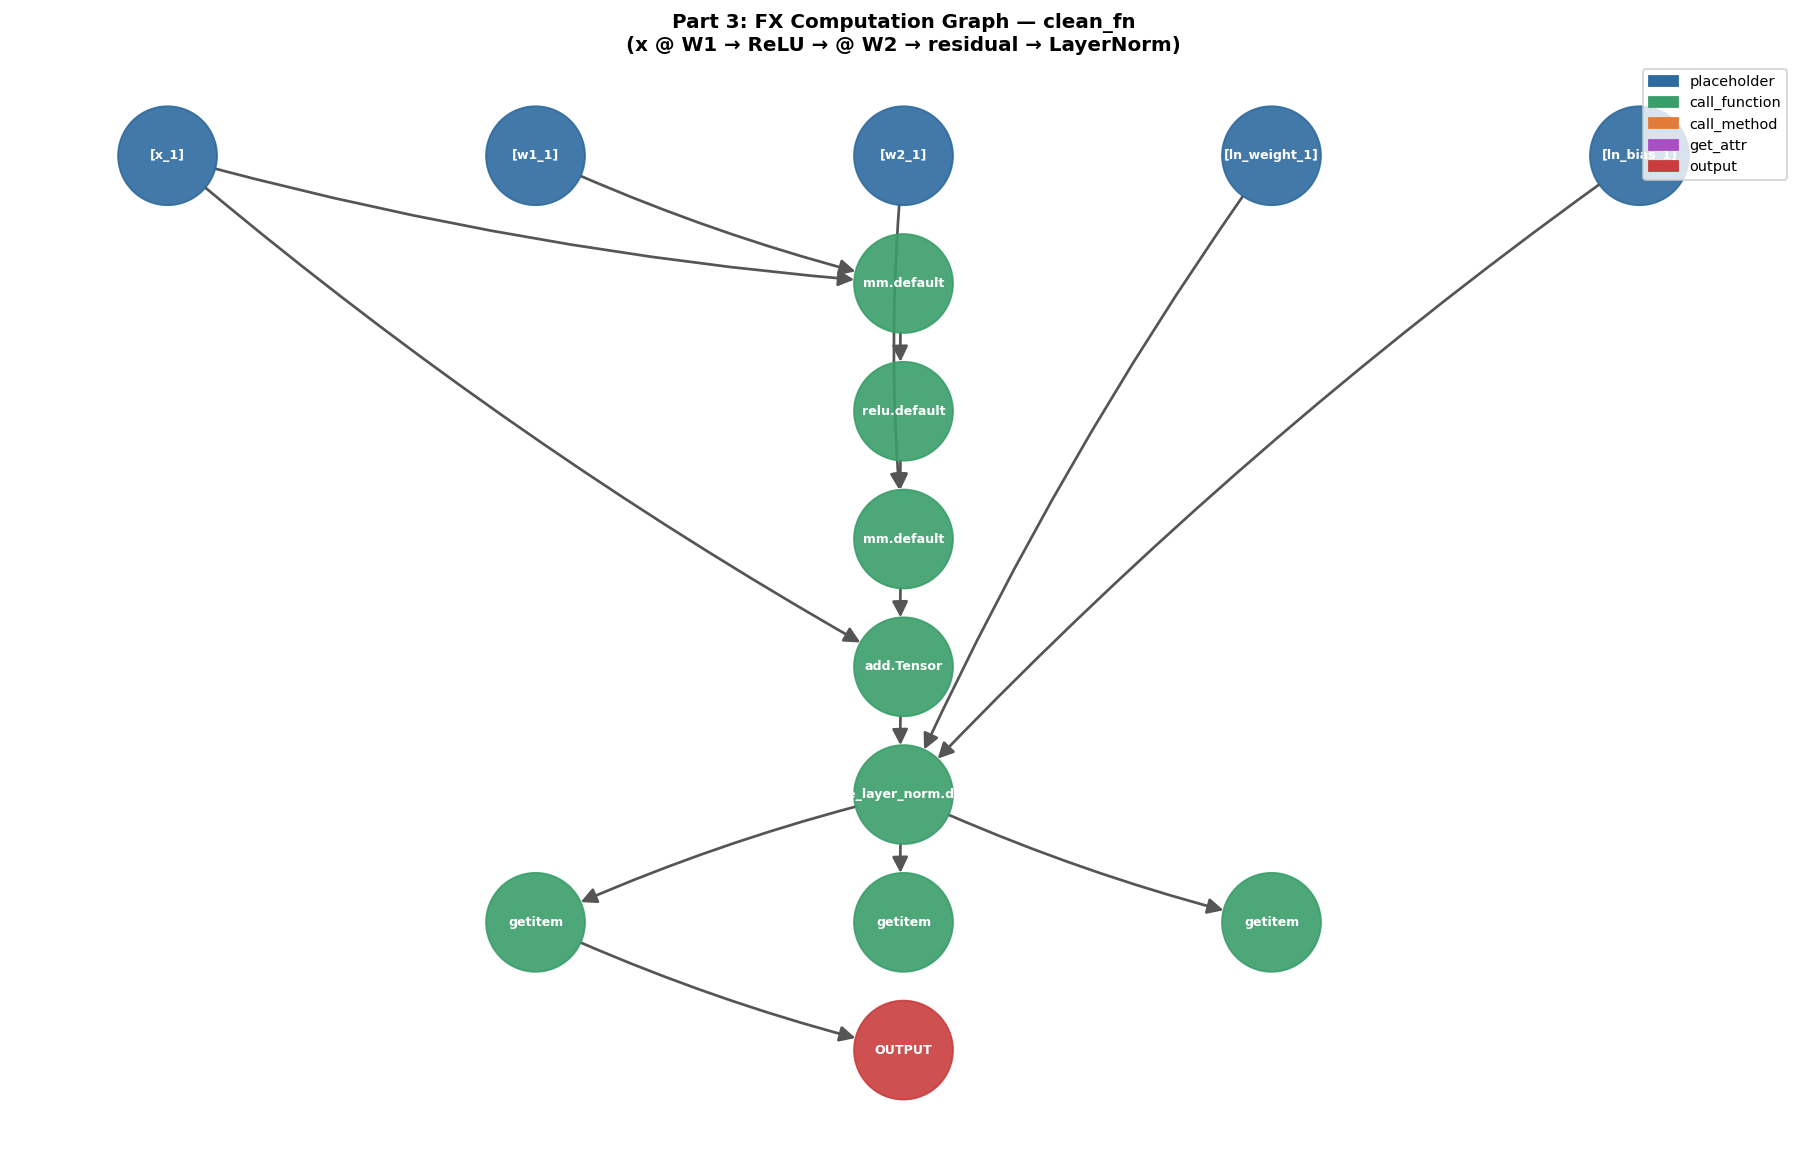

Saved: part3_fx_graph.png


In [33]:
# ── Parse the FX graph into a NetworkX DAG for visualisation ──────────────

def fx_to_networkx(graph: fx.Graph):
    """Convert an FX graph to a NetworkX DiGraph for drawing."""
    G = nx.DiGraph()
    # Node metadata
    for node in graph.nodes:
        label = f"{node.op}\n{node.name}"
        if node.op == 'call_function':
            fn_name = getattr(node.target, '__name__', str(node.target))
            label   = fn_name.replace('torch._C._nn.', '')
            label   = label.replace('torch.ops.aten.', '')
        elif node.op == 'call_method':
            label = f".{node.target}()"
        elif node.op in ('placeholder', 'get_attr'):
            label = f"[{node.name}]"
        elif node.op == 'output':
            label = 'OUTPUT'
        G.add_node(node.name, label=label, op=node.op)

    # Edges: each node's args that are graph nodes are inputs
    for node in graph.nodes:
        for arg in node.all_input_nodes:
            G.add_edge(arg.name, node.name)
    return G

G = fx_to_networkx(traced.graph)

# ── Draw the computation graph ─────────────────────────────────────────────
OP_COLORS = {
    'placeholder' : '#2D6A9F',
    'call_function': '#3A9E6A',
    'call_method'  : '#E07B39',
    'get_attr'     : '#A94EC3',
    'output'       : '#C93D3D',
}

fig, ax = plt.subplots(figsize=(14, 9))

# Hierarchical layout via graphviz_layout if available, else spring
try:
    from networkx.drawing.nx_agraph import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except Exception:
    # Fallback: manual layered layout based on topological generations
    generations = list(nx.topological_generations(G))
    pos = {}
    for gen_idx, gen in enumerate(generations):
        gen = list(gen)
        for node_idx, node in enumerate(gen):
            x_coord = node_idx - len(gen) / 2
            y_coord = -gen_idx
            pos[node] = (x_coord * 2.2, y_coord * 1.8)

node_colors = [OP_COLORS.get(G.nodes[n]['op'], '#888888') for n in G.nodes]
labels      = {n: G.nodes[n]['label'] for n in G.nodes}

nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=18,
                       edge_color='#555555', width=1.5,
                       node_size=3000,
                       connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=3000, alpha=0.90)
nx.draw_networkx_labels(G, pos, labels, ax=ax,
                        font_size=7, font_color='white', font_weight='bold')

# Legend
legend_patches = [mpatches.Patch(color=c, label=op)
                  for op, c in OP_COLORS.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
ax.set_title('Part 3: FX Computation Graph — clean_fn\n'
             '(x @ W1 → ReLU → @ W2 → residual → LayerNorm)',
             fontweight='bold', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig('part3_fx_graph.png', bbox_inches='tight', dpi=140)
plt.show()
print('Saved: part3_fx_graph.png')

In [34]:
# ── Annotated node table ───────────────────────────────────────────────────
print(f"{'Node':<28} {'Op':<18} {'Target':<35} {'Inputs'}")
print("─" * 100)
for node in traced.graph.nodes:
    target = str(getattr(node.target, '__name__', node.target))[:34]
    inputs = ', '.join(n.name for n in node.all_input_nodes)
    print(f"{node.name:<28} {node.op:<18} {target:<35} {inputs}")

Node                         Op                 Target                              Inputs
────────────────────────────────────────────────────────────────────────────────────────────────────
x_1                          placeholder        x_1                                 
w1_1                         placeholder        W1_1                                
w2_1                         placeholder        W2_1                                
ln_weight_1                  placeholder        ln_weight_1                         
ln_bias_1                    placeholder        ln_bias_1                           
mm                           call_function      mm.default                          x_1, w1_1
relu                         call_function      relu.default                        mm
mm_1                         call_function      mm.default                          relu, w2_1
add                          call_function      add.Tensor                          mm_1, x_1
native_layer_

### Part 3 Analysis

**Which operations appear in the graph?**

The FX graph captures every *tensor operation*:
- `mm` (matrix multiplication) × 2 — the two `@ W` operations
- `relu` — activation
- `add` — residual connection (`h + x`)
- `native_layer_norm` — fused LayerNorm kernel (mean, variance, normalise, affine in one op)

**Which operations are NOT captured? Why?**

| Operation | Captured? | Reason |
|-----------|-----------|--------|
| `print("Hello")` | ❌ No | Python I/O — no tensor output, no FX node type exists for it |
| `list.append(...)` | ❌ No | Python mutation of an external object — side-effect outside the tensor graph |

**What happens to `print`?**
Dynamo inserts a **graph break** at the `print` call. Everything before it forms sub-graph 1; everything after forms sub-graph 2. The `print` itself is replayed by the Python interpreter between the two sub-graphs — so it *does* execute, but it prevents the two surrounding computation blocks from being fused into a single optimised kernel.

**What happens to `list.append`?**
Same treatment: graph break, Python-side replay. The list *is* modified (the shape value is appended), but this operation cannot be part of the compiled graph and prevents cross-boundary fusion.

**Practical takeaway:** To get a single fully-fused compiled graph, remove all Python side-effects from hot paths. If you need logging, accumulate into tensors and extract Python values *outside* the compiled function.

In [18]:
# ── Final summary ──────────────────────────────────────────────────────────
print(textwrap.dedent("""
╔══════════════════════════════════════════════════════════════════════╗
║           SUMMARY: torch.compile Analysis                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Part 1 — Backends                                                   ║
║  • eager      : baseline, no compilation                             ║
║  • aot_eager  : removes backward Python overhead, minimal gain       ║
║  • inductor   : Triton kernel codegen, best steady-state perf        ║
║  • cudagraphs : zero launch overhead, best for static-shape loops    ║
║                                                                      ║
║  Part 2 — Debugging                                                  ║
║  • Data-dependent if → use torch.where                               ║
║  • Dict/list with tensors → pass directly or use namedtuple          ║
║  • Python int accumulator → initialise as torch.zeros()              ║
║  • Loop with repeated scalar ops → vectorise with torch.stack        ║
║                                                                      ║
║  Part 3 — Graph Capture                                              ║
║  • Tensor ops (mm, relu, add, layer_norm) → IN the graph ✅          ║
║  • print(), list.append() → graph breaks, Python replay ❌           ║
║  • fullgraph=True raises on any break → use for strict validation    ║
║  • make_fx gives the raw FX IR before backend-specific lowering      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""))


╔══════════════════════════════════════════════════════════════════════╗
║           SUMMARY: torch.compile Analysis                           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Part 1 — Backends                                                   ║
║  • eager      : baseline, no compilation                             ║
║  • aot_eager  : removes backward Python overhead, minimal gain       ║
║  • inductor   : Triton kernel codegen, best steady-state perf        ║
║  • cudagraphs : zero launch overhead, best for static-shape loops    ║
║                                                                      ║
║  Part 2 — Debugging                                                  ║
║  • Data-dependent if → use torch.where                               ║
║  • Dict/list with tensors → pass directly or use namedtuple          ║
║  • Python int accumulator → initialise as torch.z